In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# Import the fashion_mnist datase
from tensorflow.keras.datasets import fashion_mnist

# Split the dataset into train and test
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.losses import sparse_categorical_crossentropy

# A CNN model with the following layers:
model = Sequential()
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

C:\Users\SANJANA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:


# Trains the CNN on the training data for 5 epochs.

model.fit(x_train, y_train, epochs=5)


Epoch 1/5


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=uint8)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:

# Evaluate the model
metrics = model.evaluate(x_test, y_test)

In [6]:

# Print the metrics
metrics


[0.3281156122684479, 0.8870999813079834]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Predicted: Shirt
Actual: Shirt
Correct Label Predicted


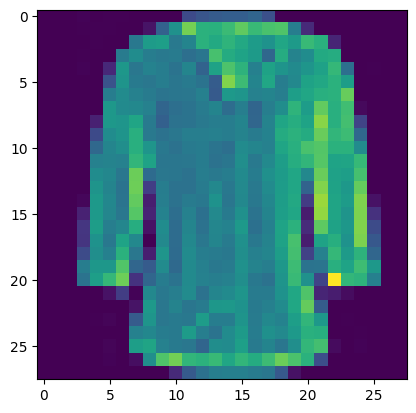

In [7]:

# Predicts label for 5th test image (image_index = 4)
image_index = 4
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

prediction = model.predict(x_test[image_index:image_index+1])
predicted_label = np.argmax(prediction)
true_label = y_test[image_index]

print(f"Predicted: {class_names[predicted_label]}")
print(f"Actual: {class_names[true_label]}")


# Compares it with actual label and prints result.
if np.argmax(prediction) == y_test[image_index]:
    print("Correct Label Predicted")
else:
    print("Incorrect Label Predicted")


# Displays the image using imshow
plt.imshow(x_test[image_index:image_index+1][0])